In [ ]:
import os

path = "/content/drive/MyDrive/diaugeia"


In [ ]:
import zipfile
import os

# Construct the full path to the zip file
zip_file_path = os.path.join(path, 'extracted_new.zip')

# Specify the directory to extract to (current directory)
extraction_path = '.'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped successfully to '{extraction_path}'")

'/content/drive/MyDrive/diaugeia/extracted_new.zip' unzipped successfully to '.'


In [ ]:
files = os.listdir("/content/extracted_new")

len(files)

1061438

In [ ]:
from sentence_transformers import SentenceTransformer
import os
from typing import List, Dict, Union, Tuple
import numpy as np # For numpy.ndarray type hint

# Load the model once globally for efficiency
model = SentenceTransformer('all-MiniLM-L6-v2')

def embed_markdown_files(markdown_filepaths: List[str]) -> List[Tuple[str, Union[np.ndarray, None]]]:
    """
    Reads multiple Markdown files, encodes their content using a SentenceTransformer model,
    and returns a list of (filepath, embedding) tuples.

    Args:
        markdown_filepaths (List[str]): A list of paths to the Markdown files.

    Returns:
        List[Tuple[str, Union[numpy.ndarray, None]]]: A list where each tuple contains the
                                        filepath and its corresponding embedding.
                                        Files that cannot be read will have None as embedding.
    """
    contents_to_encode = []
    # Store original file paths in order, and track if content was successfully read
    original_file_info: List[Tuple[str, bool]] = [] # (filepath, content_read_successfully)

    for filepath in markdown_filepaths:
        if not os.path.exists(filepath):
            # print(f"Error: File not found at {filepath}") # Uncomment for verbose error
            original_file_info.append((filepath, False))
            continue

        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                contents_to_encode.append(f.read())
                original_file_info.append((filepath, True))
        except Exception as e:
            # print(f"Error reading file {filepath}: {e}") # Uncomment for verbose error
            original_file_info.append((filepath, False))
            # No content to add to contents_to_encode for this file

    # Encode all valid contents in a batch
    encoded_embeddings = model.encode(contents_to_encode, show_progress_bar=False) # Disable progress bar for sub-batches

    # Reconstruct the results to map embeddings back to original file paths
    result_embeddings: List[Tuple[str, Union[np.ndarray, None]]] = []
    current_encoded_idx = 0
    for filepath, content_read_successfully in original_file_info:
        if content_read_successfully:
            result_embeddings.append((filepath, encoded_embeddings[current_encoded_idx]))
            current_encoded_idx += 1
        else:
            result_embeddings.append((filepath, None))

    return result_embeddings

print("Function `embed_markdown_files` defined and model initialized globally.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Function `embed_markdown_files` defined and model initialized globally.


In [ ]:
from tqdm.notebook import tqdm


# Prepend the directory path to all filenames to get full paths
file_paths = [os.path.join('/content/extracted_new', f) for f in os.listdir("/content/extracted_new")]

embeddings = {}
batch_size = 512 # Adjust this batch size based on memory and performance
num_batches = (len(file_paths) + batch_size - 1) // batch_size

for i in tqdm(range(num_batches), desc="Processing batches"):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(file_paths))
    current_batch_paths = file_paths[start_idx:end_idx]

    batch_results = embed_markdown_files(current_batch_paths)

    for filepath, embedding in batch_results:
        if embedding is not None:
            embeddings[filepath] = embedding

print(f"Processed {len(embeddings)} files and stored their embeddings.")
print(f"Total files in directory: {len(files)}")
# Display a sample of the embeddings dictionary (first 3 entries)
print("\nSample embeddings (first 3 entries):")
for i, (filepath, embedding) in enumerate(embeddings.items()):
    if i >= 3:
        break
    print(f"  File: {filepath}, Embedding shape: {embedding.shape}")
    print(f"  First 5 elements: {embedding[:5]}")

Processing batches:   0%|          | 0/1087 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import pickle

with open("/content/drive/MyDrive/embeddings_diaugeia_all_MiniLM_L6_v2.pkl", "wb") as f:
    pickle.dump(embeddings, f)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import Dict
from sklearn.decomposition import IncrementalPCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances

def visualize_embeddings_efficient(
    embeddings: Dict[str, np.ndarray],
    distance_metric: str = "cosine",
    bins: int = 200,
    chunk_size: int = 1024,
    knn_k: int = 5,
    pca_batch: int = 1024,
):
    """
    Efficient visualization for large embedding sets:
    - Incremental histogram of pairwise distances (no NxN in memory)
    - k-NN distances distribution
    - Incremental PCA (2D) scatter plot

    Args:
        embeddings: dict filepath -> np.ndarray
        distance_metric: "cosine" or "euclidean"
        bins: number of histogram bins for distance distribution
        chunk_size: rows to process per chunk when building histogram
        knn_k: number of nearest neighbours to compute per point
        pca_batch: batch size for IncrementalPCA
    """
    if not embeddings:
        print("No embeddings provided.")
        return

    filepaths = list(embeddings.keys())
    X = np.vstack(list(embeddings.values())).astype(np.float32)
    n, dim = X.shape
    print(f"Embeddings: {n} points, dim={dim}")

    # ---------- 1) Setup distance range ----------
    if distance_metric == "cosine":
        # cosine_distances returns range approximately [0, 2]
        dist_min, dist_max = 0.0, 1.0
        pairwise_fn = cosine_distances
    elif distance_metric == "euclidean":
        # estimate a reasonable max by sampling a subset (cheap)
        sample = X[np.random.choice(n, min(n, 1000), replace=False)]
        es = euclidean_distances(sample, sample)
        dist_min, dist_max = float(es.min()), float(es.max())
        pairwise_fn = euclidean_distances
    else:
        raise ValueError("distance_metric must be 'cosine' or 'euclidean'")

    bin_edges = np.linspace(dist_min, dist_max, bins + 1)
    hist_counts = np.zeros(bins, dtype=np.int64)
    total_pairs = 0

    # ---------- 2) Incremental histogram over upper triangle ----------
    # We'll iterate in row-chunks and for each row only consider columns with global_col > global_row
    for row_start in range(0, n, chunk_size):
        row_end = min(n, row_start + chunk_size)
        X_chunk = X[row_start:row_end]  # shape (chunk, dim)

        # compute distances chunk x n (fits in memory because chunk_size is small)
        D_chunk = pairwise_fn(X_chunk, X)  # shape (chunk, n)

        # For each row in chunk, take only distances to columns with global_index > row_index
        for i in range(row_end - row_start):
            global_row = row_start + i
            if global_row + 1 >= n:
                continue
            vec = D_chunk[i, global_row + 1 :]  # distances to upper-triangle columns
            if vec.size == 0:
                continue
            # update histogram counts incrementally
            c, _ = np.histogram(vec, bins=bin_edges)
            hist_counts += c
            total_pairs += vec.size

    if total_pairs == 0:
        print("Not enough pairs to compute distances (n must be >=2).")
        return

    # convert histogram to densities / cdf if desired
    hist_density = hist_counts / total_pairs
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0


    import pickle

    data = {
        "bin_centers": bin_centers,
        "hist_density": hist_density
    }

    with open("distance_distribution.pkl", "wb") as f:
        pickle.dump(data, f)

    # ---------- 3) Plot distance distribution (line) ----------
    plt.figure(figsize=(9,3), dpi=200)

    plt.plot(bin_centers, hist_density, linewidth=4.2, color="#D58500")
    # plt.title(f"Cosine Similarity Distribution")
    plt.xlabel("Cosine Similarity", fontsize=25)
    plt.ylabel("Probability density", fontsize=25)
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ---------- 4) k-NN distances (useful for 'nearest' distribution) ----------
    # We compute nearest neighbours for each point; NearestNeighbors is efficient and does not build NxN.
    nbrs = NearestNeighbors(n_neighbors=min(knn_k + 1, n), metric=distance_metric if distance_metric=="euclidean" else "cosine", n_jobs=-1)
    nbrs.fit(X)
    distances_knn, indices_knn = nbrs.kneighbors(X)  # distances shape (n, k+1) (first col is zero - self)
    # drop the zero-self distance
    knn_dists = distances_knn[:, 1:]  # shape (n, k)
    # flatten and get stats
    knn_flat = knn_dists.ravel()
    print(f"k-NN distances: k={knn_k}, mean={knn_flat.mean():.4f}, median={np.median(knn_flat):.4f}, min={knn_flat.min():.4f}, max={knn_flat.max():.4f}")

    plt.figure(figsize=(9,4))
    # plot sorted nearest-neighbour distances (use medians per-point or flatten)
    per_point_first_nn = knn_dists[:,0]
    plt.plot(np.sort(per_point_first_nn), label='1st NN distance (sorted)')
    plt.title("Sorted 1st nearest-neighbour distances")
    plt.xlabel("Point index (sorted)")
    plt.ylabel("Distance to nearest neighbour")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # ---------- 5) Incremental PCA 2D ----------
    ipca = IncrementalPCA(n_components=2)
    for start in range(0, n, pca_batch):
        ipca.partial_fit(X[start:start+pca_batch])

    # transform in batches to avoid creating a full matrix if extremely large
    X_pca = np.zeros((n, 2), dtype=np.float32)
    for start in range(0, n, pca_batch):
        end = min(n, start + pca_batch)
        X_pca[start:end] = ipca.transform(X[start:end])

    # ---------- 6) PCA scatter plot ----------
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], s=25, alpha=0.7, edgecolor='k', linewidth=0.2)
    plt.title("Incremental PCA projection (2D)")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.grid(alpha=0.25)

    # annotate a few points (keep limited to avoid clutter)
    for i, fp in enumerate(filepaths[:40]):
        plt.text(X_pca[i,0], X_pca[i,1], os.path.basename(fp)[:12], fontsize=7, alpha=0.8)

    plt.show()

    print("Done. Histogram bins:", bins, "Chunk size:", chunk_size, "k-NN:", knn_k, "PCA batch:", pca_batch)

Embeddings: 228864 points, dim=384


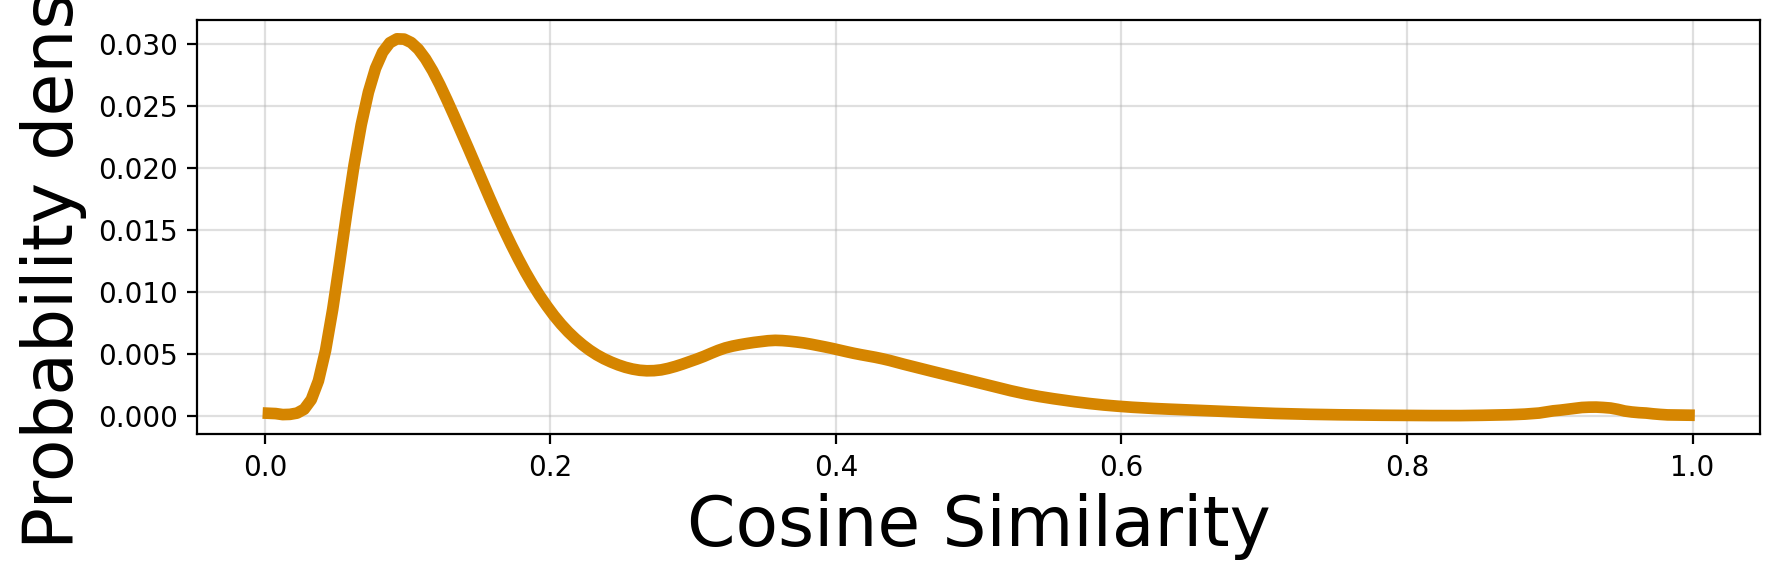

In [ ]:
visualize_embeddings_efficient(embeddings, distance_metric="cosine")

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
import os
from typing import Dict, List

def cluster_embeddings(
    embeddings: Dict[str, np.ndarray],
    n_clusters: int = 10,
    distance_metric: str = "cosine"
):
    """
    Performs K-means clustering on embeddings and finds:
      - The center of each cluster
      - The file closest to each center
      - The two closest neighbors to that center
    Returns structured results with filenames and distances.

    Args:
        embeddings (Dict[str, np.ndarray]): Mapping from filepath -> embedding.
        n_clusters (int): Number of clusters.
        distance_metric (str): 'cosine' or 'euclidean'.

    Returns:
        Dict[int, Dict[str, Any]]: Info per cluster:
            {
                cluster_id: {
                    'center': np.ndarray,
                    'center_file': str,
                    'closest_files': [str, str, str],
                    'distances': [float, float, float]
                },
                ...
            }
    """
    if not embeddings:
        print("No embeddings provided.")
        return {}

    filepaths = np.array(list(embeddings.keys()))
    X = np.vstack(list(embeddings.values())).astype(np.float32)

    print(f"Clustering {len(X)} embeddings of dim {X.shape[1]} into {n_clusters} clusters...")

    # --- Perform clustering ---
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    # --- Choose distance function ---
    if distance_metric == "cosine":
        dist_fn = cosine_distances
    elif distance_metric == "euclidean":
        dist_fn = euclidean_distances
    else:
        raise ValueError("Unsupported distance metric. Use 'cosine' or 'euclidean'.")

    cluster_info = {}

    # --- For each cluster, find closest files to center ---
    for cid in range(n_clusters):
        idx = np.where(labels == cid)[0]
        X_cluster = X[idx]
        if len(X_cluster) == 0:
            continue

        center = centers[cid].reshape(1, -1)
        dists = dist_fn(center, X_cluster)[0]  # distances to center

        # sort by distance ascending
        sorted_idx = np.argsort(dists)
        top3_idx = sorted_idx[:20] if len(sorted_idx) >= 3 else sorted_idx
        top3_files = filepaths[idx[top3_idx]]
        top3_dists = dists[top3_idx]

        cluster_info[cid] = {
            "center": center.flatten(),
            "center_file": top3_files[0],
            "closest_files": list(top3_files),
            "distances": list(top3_dists)
        }

    # --- Print summary ---
    # print(f"Found {len(cluster_info)} clusters.")
    # for cid, info in cluster_info.items():
    #     print(f"\nCluster {cid}:")
    #     print(f"  Center file: {os.path.basename(info['center_file'])}")
    #     print(f"  Closest 3 files:")
    #     for f, d in zip(info["closest_files"], info["distances"]):
    #         print(f"    {os.path.basename(f)}  (distance={d:.4f})")

    return cluster_info

In [ ]:
cluster_results = cluster_embeddings(embeddings, n_clusters=5, distance_metric="cosine")

Clustering 228864 embeddings of dim 384 into 5 clusters...
Found 5 clusters.

Cluster 0:
  Center file: 9ΘΚΚ469ΗΕΒ-8ΒΙ.md
  Closest 3 files:
    9ΘΚΚ469ΗΕΒ-8ΒΙ.md  (distance=0.0181)
    9Ο7Ν469Β4Μ-ΖΩΗ.md  (distance=0.0184)
    68Ξ8469ΗΕΒ-3ΝΙ.md  (distance=0.0194)
    6ΚΛ9469Β4Μ-Σ7Ε.md  (distance=0.0194)
    ΡΗΣΤ46Ψ8ΧΒ-1Ν4.md  (distance=0.0195)
    6ΤΕΒ46Ψ8ΧΒ-Ξ5Τ.md  (distance=0.0197)
    6Η2Ε469ΗΕΒ-0Ο6.md  (distance=0.0198)
    Ε7ΕΟ46Ψ8ΧΒ-Λ3Ζ.md  (distance=0.0201)
    9Α4Ξ469ΗΕΒ-1ΤΧ.md  (distance=0.0202)
    6Κ8Ξ469Β4Μ-ΛΤΝ.md  (distance=0.0202)
    6Ζ2Τ469ΗΕΒ-ΛΝΔ.md  (distance=0.0205)
    60Χ6469ΗΕΒ-ΓΟΨ.md  (distance=0.0205)
    9ΟΚΔ46Ψ8ΧΒ-ΔΧ2.md  (distance=0.0205)
    Ψ38946Ψ8ΧΒ-2Χ9.md  (distance=0.0206)
    9ΖΘΚ469ΗΕΒ-ΕΒΨ.md  (distance=0.0208)
    6Μ6Ε469Β4Μ-ΔΕ9.md  (distance=0.0211)
    6ΠΡΡ46Ψ8ΧΒ-ΚΓΗ.md  (distance=0.0212)
    93ΚΡ469ΗΕΒ-70Β.md  (distance=0.0212)
    9ΛΒΤ469ΗΕΒ-Θ4Τ.md  (distance=0.0212)
    ΡΒΞΦ46Ψ8ΧΒ-ΝΧΕ.md  (distance=0.0213)

Cluster 1:
  Center file: 6ΘΑΥ465ΖΩ5-1

In [ ]:
def read_txt_file(filepath):

    # filepath = f"/content/extracted_new/{filepath}"
    """Reads a text file and returns its content as a string."""
    with open(filepath, 'r', encoding='utf-8') as f:
        return f.read()

In [ ]:
import pickle

with open("/content/drive/MyDrive/embeddings_diaugeia_all_MiniLM_L6_v2.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [ ]:
"""
Example: Boilerplate detector using an LLM.
The model receives a base document and a set of related documents in XML
and must answer ONLY: "true" (boilerplate exists) or "false" (no boilerplate).
"""

from typing import List

# ---------- Prompt builders ----------

def build_related_docs_xml(related_docs: List[str]) -> str:
    """
    Turn a list of related documents into XML-like tags.
    """
    xml_parts = []
    for i, doc in enumerate(related_docs, start=1):
        xml_parts.append(f"<document id=\"{i}\">\n{doc}\n</document>")
    return "\n".join(xml_parts)


def build_boilerplate_prompt(base_document: str, related_documents: List[str]) -> str:
    """
    Build the XML prompt for the LLM.
    The model will be instructed to reply with 'true' or 'false' only.
    """
    related_docs_xml = build_related_docs_xml(related_documents)

    prompt = f"""\
<task>
  <role>
    You are an expert text analyst specialized in detecting boilerplate templates
    across multiple documents.

    In this context, "boilerplate" means text that is:
      - highly repetitive and standardized across many documents, and
      - reused with little or no meaningful modification.
    Typical examples include:
      - standard legal disclaimers
      - generic introductions or closing paragraphs used in all documents
      - fixed templates for descriptions, company profiles, or policies
      - repetitive copyright or licensing sections
      - standard form paragraphs that are copy–pasted with only minor details changed
        (such as names, dates, or IDs)

    Boilerplate is **not**:
      - content that is conceptually similar but written in clearly different wording
      - unique, document-specific analysis, arguments, or narratives
      - small overlaps like common phrases or generic sentences that could appear anywhere

    Your job is to decide whether the base document contains boilerplate content
    that clearly matches text found in the related documents. You do NOT need
    to find matches across all of them — some documents may contain no boilerplate
    and that is acceptable. However, whenever a match is detected, it must be a
    strong, fixed boilerplate segment: not just loosely similar phrasing, but a
    clearly repeated template section that appears in essentially identical form
    between the base document and at least one related document. Partial loose
    resemblance is not enough — the matching portion must be a near-exact or exact
    boilerplate block reused verbatim.

  </role>

  <instructions>
    1. Carefully read the base document.
    2. Carefully read all related documents.
    3. Look for sections in the base document that are:
         - identical or almost identical (with only minimal edits)
         - clearly reused template text that appears across several related documents.
    4. If you find such boilerplate sections in the base document
       that are reused across multiple related documents,
       output "true".
    5. If the base document does NOT contain such repeated template text,
       output "false".
    6. You MUST output ONLY one of these two lowercase strings:
         - "true"
         - "false"
       with no explanation, no extra characters, and no additional text.
  </instructions>

  <base_document>
{base_document}
  </base_document>

  <related_documents>
{related_docs_xml}
  </related_documents>

  <output_format>
    Reply with ONLY:
      - "true"  if boilerplate exists in the base document
      - "false" if no boilerplate is detected
  </output_format>
</task>
"""
    return prompt


def build_boilerplate_extraction_prompt(base_document: str, related_documents: List[str]) -> str:
    """
    Follow-up XML prompt after template detection.
    Strict extraction of boilerplate segments vs unique content.
    The output must be the original text with XML segmentation only.
    """

    related_docs_xml = build_related_docs_xml(related_documents)

    prompt = f"""\
<task>
  <role>
    You are a precision document segmentation system designed to extract boilerplate text
    EXTREMELY STRICTLY. Your output will separate the base document into:
      - exact boilerplate segments (verbatim template reuse)
      - unique content segments (new semantic material)

    Boilerplate must only be labelled when there is strong evidence of near-identical reuse
    across other documents. Similar phrasing or thematic overlap is NOT enough.
    Paraphrased or conceptually similar text MUST be classified as <main_content>.

    Treat this task conservatively: if unsure, prefer assigning text to <main_content>.
  </role>

  <instructions>
    1. Compare the base document with the other documents.
    2. Mark ONLY the segments that match in almost identical wording as <template>.
       - If the text is paraphrased or loosely similar → it is NOT template.
       - Exact/near-exact duplication → template.
    3. Mark all remaining text as <main_content>.
    4. Preserve original order and wording EXACTLY. No rewriting, no deletion.
    5. Output ONLY the segmented document in XML, with NO explanation.

    Conservative rule:
        If there is any uncertainty → classify as <main_content>.
  </instructions>

  <output_format>
    Return the full document as:

    <document>
      <template> ...exact repeated boilerplate segments... </template>
      <main_content> ...all remaining text... </main_content>
    </document>

    No extra commentary, no probabilities, no analysis.
    The output must contain every original token exactly once.
  </output_format>

</task>
"""
    return prompt


# ---------- Example of how you might call an LLM (OpenAI-style pseudocode) ----------

from openai import OpenAI

os.environ["OPENAI_API_KEY"] = ""


def classify_boilerplate(base_doc, related_docs):
    # base_doc = "..."  # your main document text
    # related_docs = ["...", "...", "..."]  # list of related documents

    prompt = build_boilerplate_prompt(base_doc, related_docs)

    client = OpenAI()

    messages = [
            {"role": "system",
            "content": """
You are a highly reliable boilerplate analysis model designed to operate in two modes:

(1) DETECTION MODE — Identify whether a document contains boilerplate.
    Boilerplate refers to recurring, near-identical template text that appears
    across different documents. It must be reused with little to no modification.
    Similar meaning is not enough — wording must be nearly identical.
    When performing detection, you MUST answer only with:
        "true"  (boilerplate present)
        "false" (no boilerplate found)

(2) EXTRACTION MODE — If boilerplate exists, segment the document.
    Your job is to extract exact boilerplate sections and separate them from
    unique textual material. Produce the full original document with XML markup:
        <template> ...exact boilerplate segments... </template>
        <main_content> ...all remaining text... </main_content>
    Similar or paraphrased passages MUST NOT be marked as template.
    Only near-verbatim repeated text qualifies as boilerplate.
    Preserve every token exactly once. No rewriting, no paraphrasing.

General Behaviour Requirements:
- Be conservative. If uncertain → classify as main_content.
- No explanations unless explicitly asked.
- Maintain full integrity of original text when segmenting.
- Exact-matching boilerplate takes priority over semantic similarity.
- In detection mode, answer ONLY true/false — no other output.
            """},
            {"role": "user", "content": prompt},
        ]
    response = client.chat.completions.create(
        model="gpt-5",
        messages=messages
    )

    raw_answer = response.choices[0].message.content.strip()
    messages.append({"role": "assistant", "content": raw_answer})
    is_boilerplate = (raw_answer == "true")   # boolean True/False in Python

    if is_boilerplate:
        messages.append(
            {
                "role": "assistant",
                "content":build_boilerplate_extraction_prompt(base_doc, related_docs)
            }
        )

        response = client.chat.completions.create(
            model="gpt-5",
            messages=messages
        )

        raw_answer_templates = response.choices[0].message.content.strip()

    else:
        raw_answer_templates = ""

    # print(is_boilerplate, raw_answer_templates)

    return is_boilerplate, raw_answer_templates

In [ ]:
# Analysis

# import time

# cluster_results_boilerplate = {}
# for n_clusters in  [50, 100]:

#     cluster_results = cluster_embeddings(embeddings, n_clusters=n_clusters, distance_metric="cosine")

#     count = {"True": 0, "False": 0}
#     for cluster_id in cluster_results:
#         base_file = str(cluster_results[cluster_id]["center_file"])

#         related_docs = [str(filename) for filename in cluster_results[cluster_id]["closest_files"]]

#         base_doc = read_txt_file(base_file)

#         related_docs = [read_txt_file(filename) for filename in related_docs]

#         cl = classify_boilerplate(base_doc, related_docs)

#         if cl in count:
#             count[cl] += 1
#         else:
#             count[cl] = 1

#         time.sleep(5)

#     cluster_results_boilerplate[n_clusters] = count.copy()

#     print (cluster_results_boilerplate)


In [ ]:
def normalized_word_level_levenshtein(s1: str, s2: str) -> float:
    # Split σε λέξεις αντί για χαρακτήρες
    words1 = s1.split()
    words2 = s2.split()

    # Πίνακας Dynamic Programming
    m, n = len(words1), len(words2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    # Αρχικοποίηση
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    # Υπολογισμός Levenshtein distance σε επίπεδο λέξεων
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if words1[i-1] == words2[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,      # διαγραφή
                dp[i][j-1] + 1,      # εισαγωγή
                dp[i-1][j-1] + cost  # αντικατάσταση
            )

    distance = dp[m][n]

    # Normalization
    max_len = max(m, n)
    return distance / max_len if max_len > 0 else 0.0


# Παράδειγμα χρήσης
s1 = "I like deep learning models"
s2 = "I enjoy deep neural network architectures"

print(normalized_word_level_levenshtein(s1, s2))

0.6666666666666666


In [ ]:
from typing import Dict, List
from tqdm import tqdm

# sizes = []

# for filename in tqdm(embeddings.keys()):
#     try:
#         text = read_txt_file(filename)   # <-- χρησιμοποιείς τη δική σου υλοποίηση
#         sizes.append((filename, len(text)))
#     except Exception as e:
#         print(f"[WARNING] Failed to read {filename}: {e}")

#     if len(sizes) > 120000:
#         break

# sizes.sort(key=lambda x: x[1])

base_filenames = [f for f, t in sizes if t > 100]

base_filenames = base_filenames[40000:40100]

base_docs = [read_txt_file(filename) for filename in base_filenames]

In [ ]:
from typing import Dict, List, Tuple
import numpy as np

def top_n_similar(embeddings: Dict[str, np.ndarray], query_file: str, n: int = 20
                 ) -> List[Tuple[str, float]]:
    """Επιστρέφει τα n αρχεία με τη μεγαλύτερη ομοιότητα (cosine similarity)
       σε σχέση με το query_file.
    """

    if query_file not in embeddings:
        raise ValueError(f"Το αρχείο '{query_file}' δεν υπάρχει στα embeddings.")

    query_vec = embeddings[query_file]

    def cosine_similarity(a, b):
        return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

    similarities = []
    for fname, vec in embeddings.items():
        if fname == query_file:
            continue
        sim = cosine_similarity(query_vec, vec)
        similarities.append((fname, sim))

    # Ταξινόμηση με φθίνουσα similarity (οπότε τα πιο κοντινά πρώτα)
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:n]



base_file = base_filenames[0]
closest = top_n_similar(embeddings, base_file, n=20)

related_docs = [str(name) for name, sim in closest]

base_doc = read_txt_file(base_file)

related_docs = [read_txt_file(filename) for filename in related_docs]


base_file_1 = list(closest[0])[0]
closest_1 = top_n_similar(embeddings, base_file_1, n=20)

related_docs_1 = [str(name) for name, sim in closest_1]

base_doc_1 = read_txt_file(base_file_1)

related_docs_1 = [read_txt_file(filename) for filename in related_docs_1]

In [ ]:
is_boilerplate, raw_answer_templates = classify_boilerplate(base_doc, related_docs)

True <document>
  <template>Ministry of Digital Digitally signed by Ministryof Digital Governance,
Governance, Hellenic Republic



Digitally signed by Ministry
of Digital Governance,
Hellenic Republic



**ΑΝΑΡΤΗΤΕΑ ΣΤΟ ΔΙΑΔΙΚΤΥΟ**



**ΓΡΑΜΜΑΤΕΙΑ ΕΙΔΙΚΟΥ ΛΟΓΑΡΙΑΣΜΟΥ**


**ΑΠΟΦΑΣΗ**


Η Επιτροπή Ερευνών του Ειδικού Λογαριασμού Κονδυλίων Έρευνας Α.Π.Θ. στη Συνεδρίασή της
885/25-05-2021, έχοντας υπόψη:


α. - Τις διατάξεις του άρθρου 62 παρ. 4 και του άρθρου 64 του Ν.4485/2017 (ΦΕΚ Α’ 114/4.8.2017).


β. - Τις διατάξεις της παρ. 23 του άρθρου 2 του ν.2621/1998 (ΦΕΚ.136 Α'), όπως τροποποιήθηκαν με


την παρ. 11 του άρθρου 58 του ν.4009/2011 (ΦΕΚ.195 Α') και επανήλθαν σε ισχύ με το


ν.4076/2012 (ΦΕΚ.159 Α') και εν συνεχεία τροποποιήθηκαν με το άρθρο 6 της ΠΝΠ της 30/12/2015


(ΦΕΚ.184 Α').


γ. - Το ν.3861/2010 (ΦΕΚ.112 Α'/13-07-2010) «Ενίσχυση της διαφάνειας με την υποχρεωτική


ανάρτηση νόμων και πράξεων των κυβερνητικών, διοικητικών και αυτοδιοικητικών οργάνων στο


Διαδίκτυο "Πρόγραμ

In [ ]:
is_boilerplate_1, raw_answer_templates_1 = classify_boilerplate(base_doc_1, related_docs_1)

True <document>
  <template>Ministry of Digital Digitally signed by Ministryof Digital Governance,
Governance, Hellenic Republic



Digitally signed by Ministry
of Digital Governance,
Hellenic Republic



**ΑΝΑΡΤΗΤΕΑ ΣΤΟ ΔΙΑΔΙΚΤΥΟ**



**ΓΡΑΜΜΑΤΕΙΑ ΕΙΔΙΚΟΥ ΛΟΓΑΡΙΑΣΜΟΥ**


**ΑΠΟΦΑΣΗ**


Η Επιτροπή Ερευνών του Ειδικού Λογαριασμού Κονδυλίων Έρευνας Α.Π.Θ. στη Συνεδρίασή της
885/25-05-2021, έχοντας υπόψη:


α. - Τις διατάξεις του άρθρου 62 παρ. 4 και του άρθρου 64 του Ν.4485/2017 (ΦΕΚ Α’ 114/4.8.2017).


β. - Τις διατάξεις της παρ. 23 του άρθρου 2 του ν.2621/1998 (ΦΕΚ.136 Α'), όπως τροποποιήθηκαν με


την παρ. 11 του άρθρου 58 του ν.4009/2011 (ΦΕΚ.195 Α') και επανήλθαν σε ισχύ με το


ν.4076/2012 (ΦΕΚ.159 Α') και εν συνεχεία τροποποιήθηκαν με το άρθρο 6 της ΠΝΠ της 30/12/2015


(ΦΕΚ.184 Α').


γ. - Το ν.3861/2010 (ΦΕΚ.112 Α'/13-07-2010) «Ενίσχυση της διαφάνειας με την υποχρεωτική


ανάρτηση νόμων και πράξεων των κυβερνητικών, διοικητικών και αυτοδιοικητικών οργάνων στο


Διαδίκτυο "Πρόγραμ

In [ ]:
import re
from typing import Tuple, List

def extract_blocks(xml: str) -> Tuple[List[str], List[str]]:
    """Extract <template> and <main_content> blocks from XML text."""
    templates = re.findall(r"<template>(.*?)</template>", xml, flags=re.S)
    mains = re.findall(r"<main_content>(.*?)</main_content>", xml, flags=re.S)
    return templates, mains


def merge_main_content(doc1: str, doc2: str) -> str:
    """
    Replace main_content blocks in doc1 with main_content blocks from doc2.
    - template stays from doc1
    - main_content indexes mapped one-to-one from doc2
    - if doc2 runs out → fill with empty
    """

    templates1, mains1 = extract_blocks(doc1)
    _, mains2 = extract_blocks(doc2)

    result = ["<document>"]

    # 1) Add templates from doc1 untouched
    for t in templates1:
        result.append(f"<template>{t}</template>")

    # 2) Replace main_content doc1 with doc2 index-wise
    for i in range(len(mains1)):
        new_mc = mains2[i] if i < len(mains2) else ""
        result.append(f"<main_content>{new_mc}</main_content>")

    result.append("</document>")
    return "\n".join(result)



m = merge_main_content(raw_answer_templates, raw_answer_templates_1)

In [ ]:
normalized_word_level_levenshtein(base_doc, m)

0.050746268656716415

<document>
<template>Ministry of Digital Digitally signed by Ministryof Digital Governance,
Governance, Hellenic Republic



Digitally signed by Ministry
of Digital Governance,
Hellenic Republic



**ΑΝΑΡΤΗΤΕΑ ΣΤΟ ΔΙΑΔΙΚΤΥΟ**



**ΓΡΑΜΜΑΤΕΙΑ ΕΙΔΙΚΟΥ ΛΟΓΑΡΙΑΣΜΟΥ**


**ΑΠΟΦΑΣΗ**


Η Επιτροπή Ερευνών του Ειδικού Λογαριασμού Κονδυλίων Έρευνας Α.Π.Θ. στη Συνεδρίασή της
885/25-05-2021, έχοντας υπόψη:


α. - Τις διατάξεις του άρθρου 62 παρ. 4 και του άρθρου 64 του Ν.4485/2017 (ΦΕΚ Α’ 114/4.8.2017).


β. - Τις διατάξεις της παρ. 23 του άρθρου 2 του ν.2621/1998 (ΦΕΚ.136 Α'), όπως τροποποιήθηκαν με


την παρ. 11 του άρθρου 58 του ν.4009/2011 (ΦΕΚ.195 Α') και επανήλθαν σε ισχύ με το


ν.4076/2012 (ΦΕΚ.159 Α') και εν συνεχεία τροποποιήθηκαν με το άρθρο 6 της ΠΝΠ της 30/12/2015


(ΦΕΚ.184 Α').


γ. - Το ν.3861/2010 (ΦΕΚ.112 Α'/13-07-2010) «Ενίσχυση της διαφάνειας με την υποχρεωτική


ανάρτηση νόμων και πράξεων των κυβερνητικών, διοικητικών και αυτοδιοικητικών οργάνων στο


Διαδίκτυο "Πρόγραμμα Διαύ

In [ ]:
dists = []

for base_filename_0 in tqdm(base_filenames[:50]):

    closest_0 = top_n_similar(embeddings, base_filename_0, n=20)
    related_docs_0 = [str(name) for name, sim in closest_0]

    base_doc_0 = read_txt_file(base_filename_0)
    related_docs_0 = [read_txt_file(filename) for filename in related_docs_0]


    base_file_1 = list(closest[0])[0]
    closest_1 = top_n_similar(embeddings, base_file_1, n=20)

    related_docs_1 = [str(name) for name, sim in closest_1]
    base_doc_1 = read_txt_file(base_file_1)
    related_docs_1 = [read_txt_file(filename) for filename in related_docs_1]


    dists.append({
        "base_filename_0": base_filename_0,
        "base_doc_0": base_doc_0,
        "related_docs_0: ": related_docs_0,
        "base_file_1": base_file_1,
        "base_doc_1": base_doc_1,
        "related_docs_1": related_docs_1,
    })

    # is_boilerplate_0, raw_answer_templates_0 = classify_boilerplate(base_doc_0, related_docs_0)

    # is_boilerplate_1, raw_answer_templates_1 = classify_boilerplate(base_doc_1, related_docs_1)

    # m = merge_main_content(raw_answer_templates_0, raw_answer_templates_1)

    # dist = normalized_word_level_levenshtein(base_doc, m)

    # dists.append(dist)

import pickle
with open ("dists.pkl", "wb") as f:
    pickle.dump(dists, f)

100%|██████████| 50/50 [04:14<00:00,  5.08s/it]


In [ ]:
print (np.mean(dists), np.std(dist))

0.7612275449101796 0.0


In [ ]:
import json
with open("dists.json", "w") as f:
    dists = json.dump(dists, f)

In [ ]:
dists